# Статистикалық модельдеу (СМ) vs Machine Learning (ML)
# СМ: Интерпретациялау мен гипотезаларды тексеруге көзделген. Бастысы, неліктен X айнымалы Y айнымалыға әсер етеді (мысалы, p-value, сенім интервалдары). Тек деректер туралы математикалық пайымдармен жұмыс жасайды.
# ML: Болжамның дәлдігіне көзделеді. Болжамның қалай алынуы әркез маңызды емес, бастысы  — жаңа деректермн дқрыс нәтиже алу. Пайымдауды азайтып, алгоритм мен итерацияларға сүйену.

# ML есептерінің түрлері

# Оқытушымен үйрету (Supervised): "Дұрыс жауаптар" бар (таңбалану).
##                    Классификация: Категорияларды болжаймыз (спам/спам емес, итт/мысық  тсс).
##                    Регрессия: Сандық деректерді болжау (үйдің бағасы, температура тсс).



# Оқытушысыз үйрету (Unsupervised): Таңбалар жоқ, жасырын заңдылықтарды іздейміз.
##                    Кластеризация: Ұқсас нысандарды топтастыру (клиенттерді сегменттеу).                    

# Overfitting и Underfitting
## Өткізіп (жаттатып) оқыту (Overfitting): Модель үйрететін мәліметтерді қателерін қоса алғанда, жаттап алады. Жаттығуда кезінде дәлдік 100%, ал жаңа деректерде - сәтсіздік.

###                   Сауықтыру: Регуляризациялау, көп деректер оқыту, модельді ықшамдау, аугментация.


## Жеткізбей оқыту (Underfitting): Модель өте қарапайым және заңдылықтарды байқамайды. Түгел жерде нашар жұмыс атқарады.

###                  Сауықтыру: Модельді күрделендіру, жаңа белгілер қосу (feature engineering).


# Күресудің түрлері:
##                 Валидациялау: Модель байқамай қалған деректерді тексеру.
##                 Регуляризациялау (L1/L2): Модельдегі өте басым салмақтарға тыйым салу.

## Bias (Ығысу) және Variance (Шашылу):
####             Underfitting —бұл күшті ығысу (Bias) ығысудың күштілігі (модель өте қарапайым және әрекетінің бағыты белгілі, тәуелді).
####             Overfitting — бұл күшті шашырау (Variance) (модель азғантай тербелістерге де сезімтал).

##  Регуляризациялау "(реттестіруу):
###  L1 (Lasso): нашар белгілердің салмақтарын нөлге айналдырады (белгілерге таңдау жүргізеді).
###  L2 (Ridge): ешқандай белгі доминант болмауы үшін салмақтарды кішірейтеді.



# MLOps и Docker

##    MLOps: Это как DevOps, но для нейросетей. Автоматизация жизненного цикла модели: от обучения до деплоя и мониторинга.
##    Docker: Решает проблему «у меня на компе всё работало». Контейнер упаковывает модель, код и все зависимости (библиотеки, версии Python), чтобы всё гарантированно запустилось на любом сервере.

## Docker оқшауланған қабат құрастырады. "Dockerfile" (нұсқаулық) жазылады, сосын модель осыған сәйкес барлық жерде ноутбукта, серверде, бұлтта біркелкі ортада іске қосылады.

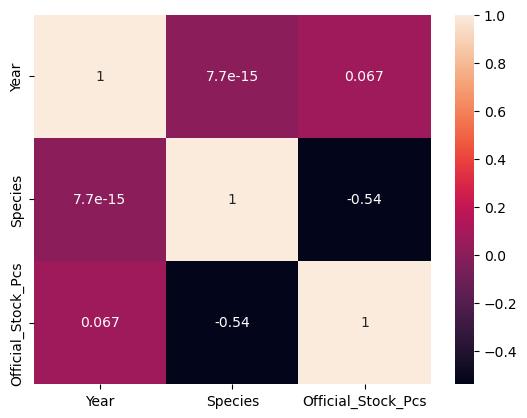

Точность модели (R^2): 0.2123156553660056


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. Загрузка и очистка
df = pd.read_csv('data.csv')
df = df.fillna(df.mean()) 

# 2. Визуализация
sns.heatmap(df.corr(), annot=True)
plt.show()

# 3. Разделение и обучение
X = df.drop('Species', axis=1)
y = df['Species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)
print(f"Точность модели (R^2): {model.score(X_test, y_test)}")

In [11]:
# Используем легковесный образ Python
#FROM python:3.9-slim

# Устанавливаем рабочую директорию
#WORKDIR /app

# Копируем зависимости и устанавливаем их
#COPY requirements.txt .
#RUN pip install --no-cache-dir -r requirements.txt

# Копируем код проекта
#COPY . .

# Команда для запуска анализа
#CMD ["python", "main.py"]

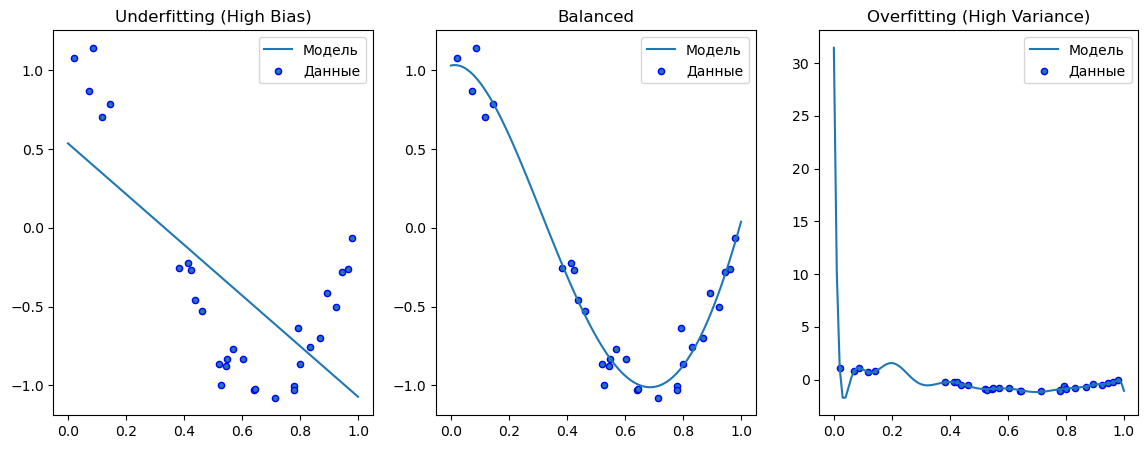

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 1. деректерді генерациялау (синусоида + шу)
np.random.seed(0)
n_samples = 30
X = np.sort(np.random.rand(n_samples))
y = np.cos(1.5 * np.pi * X) + np.random.randn(n_samples) * 0.1
X_test = np.linspace(0, 1, 100)

# салыстыруға қажетті полиномдардың дәрежесі
degrees = [1, 4, 15] # 1 - Underfitting, 4 - Good, 15 - Overfitting

plt.figure(figsize=(14, 5))
for i, degree in enumerate(degrees):
    ax = plt.subplot(1, len(degrees), i + 1)
    
    # пайплайн құру: белгілерді дәрежелеп регрессияны оқыту
    polynomial_features = PolynomialFeatures(degree=degree, include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("pf", polynomial_features), ("lr", linear_regression)])
    pipeline.fit(X[:, np.newaxis], y)

    # Визуализациялау
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Модель")
    plt.scatter(X, y, edgecolor='b', s=20, label="Данные")
    
    titles = {1: "Underfitting (High Bias)", 4: "Balanced", 15: "Overfitting (High Variance)"}
    plt.title(titles[degree])
    plt.legend(loc="best")

plt.show()